Ovaj kod roka FP growth na nacin da samo gleda je li proizvod x kupljen od strane kupca y. Dakle imamo nekakvu strukturu binarne matrice gdje su retcu kupci a stupci proizvodi.

U ovoj cliji ispod samo ucitavamo podatke i brisemo nans

In [7]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load data
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",
    low_memory=False
)
print(f"Loaded {len(df)} rows")

# Convert Item Code to string and remove NaN values
df['Item Code'] = df['Item Code'].astype(str)
df = df[df['Item Code'] != 'nan']  # Remove NaN values

print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Unique items: {df['Item Code'].nunique()}")
df[['CustomerID', 'Item Code']].head(10)

Loaded 1294962 rows
Unique customers: 12214
Unique items: 63019


,CustomerID,Item Code
0,224224,054501
1,230494,034903
2,235861,057280
3,223839,309146
4,223839,309146
5,223839,309146
6,224307,343372
7,224029,348716
8,224029,352311
9,224600,357269


Mapiranje gdje su kupci kljuc a vrijednost je set kupjenih proizvoda.

In [8]:
# Create mapping: CustomerID -> set of unique Item Codes
# Ensure CustomerID is integer and Item Code is string
df['CustomerID'] = df['CustomerID'].astype(int)
df['Item Code'] = df['Item Code'].astype(str)

customer_items = df.groupby('CustomerID')['Item Code'].apply(set).to_dict()

print(f"Number of customers (transactions): {len(customer_items)}")
print(f"\nExample (first 3 customers):")
for i, (cid, items) in enumerate(customer_items.items()):
    if i >= 3:
        break
    print(f"  Customer {cid}: {len(items)} unique items -> {list(items)[:5]}{'...' if len(items) > 5 else ''}")

Number of customers (transactions): 12214

Example (first 3 customers):
  Customer -99: 23 unique items -> ['NBO2085 Claim', nan, '429900212', '13935', 'NBO2536 Pre-Pay']...
  Customer 13: 1 unique items -> ['5DD1573B']
  Customer 16: 1 unique items -> ['5V7084-9812B']


In [ ]:
Prebacuje u format matrice

In [9]:
# Convert to list of transactions (list of sets -> list of lists)
# Ensure all items are strings (remove any NaN/float values)
transactions = [
    [str(item) for item in items if str(item) != 'nan']
    for items in customer_items.values()
]

# Remove empty transactions
transactions = [t for t in transactions if len(t) > 0]

# One-hot encode transactions
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix shape: {basket_df.shape}")
print(f"(rows = customers, columns = unique items)")
basket_df.head()

Transaction matrix shape: (12214, 63019)
(rows = customers, columns = unique items)


,F18293-000-AA,PAR540-.375,#5A0756390003,***AIR CHARGE,***EXTRA CHARGE,*/,*/MISC,*00010,*00020,*00030,...,p1625,par680-55397,pla192-0417,rma1970-31407A,sch153-155.27,tek751-0418,tek755-2081-00,tri712-890-0093,ves204-762353,ÜBERH
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Algoritam u akciji - FP-Growth. min_support je 30 arbitrazno odreden jer u statistici se 30 smatra signifikantno veliko i za sada gledam dubinu 2 kako je najlakse interpretabilna

In [13]:
# FP-Growth with min_support = min_support_count / total customers
min_support_count = 30
min_support_ratio = min_support_count / len(transactions)
print(f"Min support: {min_support_count} customers = {min_support_ratio:.4f} ratio")

# Run FP-Growth, max_len=2 (only interested in pairs)
frequent_itemsets = fpgrowth(
    basket_df,
    min_support=min_support_ratio,
    use_colnames=True,
    max_len=2
)

# Filter to only itemsets of size 2 (pairs)
frequent_pairs = frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == 2].copy()
frequent_pairs['support_count'] = (frequent_pairs['support'] * len(transactions)).round().astype(int)

print(f"\nTotal frequent itemsets: {len(frequent_itemsets)}")
print(f"  - Single items: {len(frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == 1])}")
print(f"  - Pairs: {len(frequent_pairs)}")
frequent_pairs.sort_values('support', ascending=False).head(10)

Min support: 30 customers = 0.0025 ratio

Total frequent itemsets: 556
  - Single items: 252
  - Pairs: 304

Total frequent itemsets: 556
  - Single items: 252
  - Pairs: 304


,support,itemsets,support_count
531,0.011217,"frozenset({AUSFA, TRANSPORTKOSTEN})",137
535,0.008351,"frozenset({AUSFA, NEUBS})",102
536,0.007614,"frozenset({NEUBS, TRANSPORTKOSTEN})",93
549,0.006714,"frozenset({46000, 42000})",82
544,0.006632,"frozenset({47000, SAMPLE-MPCS})",81
534,0.006304,"frozenset({TRANSPORTKOSTEN, PROGRAMM})",77
532,0.006222,"frozenset({AUSFA, PROGRAMM})",76
252,0.006059,"frozenset({/C, /LTI})",74
256,0.005649,"frozenset({*200005, *200007})",69
542,0.005649,"frozenset({47000, 46000})",69


Tablica ispod ima stupce koji govore koja 2 proizvoda gledamo vjerojatnosti za prvi proizvod, vjerojatnost za drugi i vjerojatnost za oba skupa. Support count je broj puta kada su se oba proizvoda skupa pokazali (mora bit veci od 30). Confidence nam govori uvjetno da se pokazu oba ako se prvi pojavio. Lift je vjerojatnost od oba kroz umnozak pojedinacnih.

In [16]:
# Generate association rules with lift metric
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0, num_itemsets=len(transactions))

# Keep only rules where both antecedent and consequent are single items (pair correlations)
rules = rules[
    (rules['antecedents'].apply(len) == 1) & 
    (rules['consequents'].apply(len) == 1)
].copy()

# Clean up for display
rules['antecedent'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequent'] = rules['consequents'].apply(lambda x: list(x)[0])
rules['support_count'] = (rules['support'] * len(transactions)).round().astype(int)

# Extract and explicitly name the probabilities (supports)
rules['prob_antecedent'] = rules['antecedent support']
rules['prob_consequent'] = rules['consequent support']
rules['prob_both'] = rules['support']

# Sort by lift descending
rules_sorted = rules.sort_values('lift', ascending=False)

print(f"Total association rules (lift >= 1.0): {len(rules_sorted)}")
print(f"\n{'='*80}")
print(f"TOP 30 ITEM PAIRS BY LIFT")
print(f"{'='*80}\n")

top_n = 30
display_cols = [
    'antecedent', 'consequent', 
    'prob_antecedent', 'prob_consequent', 'prob_both', 
    'support_count', 'confidence', 'lift'
]
print(rules_sorted[display_cols].head(top_n).to_string(index=False))

rules_sorted[display_cols].head(top_n)

Total association rules (lift >= 1.0): 608

TOP 30 ITEM PAIRS BY LIFT

   antecedent    consequent  prob_antecedent  prob_consequent  prob_both  support_count  confidence       lift
      1998-LH       1998-RH         0.003029         0.002620   0.002620             32    0.864865 330.108108
      1998-RH       1998-LH         0.002620         0.003029   0.002620             32    1.000000 330.108108
N100-70/2-234 N100-70/2-230         0.003193         0.004257   0.002456             30    0.769231 180.680473
N100-70/2-230 N100-70/2-234         0.004257         0.003193   0.002456             30    0.576923 180.680473
N100-70/2-230 N100-70/2-236         0.004257         0.003357   0.002538             31    0.596154 177.595685
N100-70/2-236 N100-70/2-230         0.003357         0.004257   0.002538             31    0.756098 177.595685
N100-70/2-232 N100-70/2-228         0.003848         0.004094   0.002538             31    0.659574 161.120851
N100-70/2-228 N100-70/2-232         0.004

,antecedent,consequent,prob_antecedent,prob_consequent,prob_both,support_count,confidence,lift
3,1998-LH,1998-RH,0.003029,0.002620,0.002620,32,0.864865,330.108108
2,1998-RH,1998-LH,0.002620,0.003029,0.002620,32,1.000000,330.108108
207,N100-70/2-234,N100-70/2-230,0.003193,0.004257,0.002456,30,0.769231,180.680473
206,N100-70/2-230,N100-70/2-234,0.004257,0.003193,0.002456,30,0.576923,180.680473
466,N100-70/2-230,N100-70/2-236,0.004257,0.003357,0.002538,31,0.596154,177.595685
467,N100-70/2-236,N100-70/2-230,0.003357,0.004257,0.002538,31,0.756098,177.595685
546,N100-70/2-232,N100-70/2-228,0.003848,0.004094,0.002538,31,0.659574,161.120851
547,N100-70/2-228,N100-70/2-232,0.004094,0.003848,0.002538,31,0.620000,161.120851
538,N100-70/2-232,N100-70/2-218,0.003848,0.004257,0.002456,30,0.638298,149.926350
539,N100-70/2-218,N100-70/2-232,0.004257,0.003848,0.002456,30,0.576923,149.926350


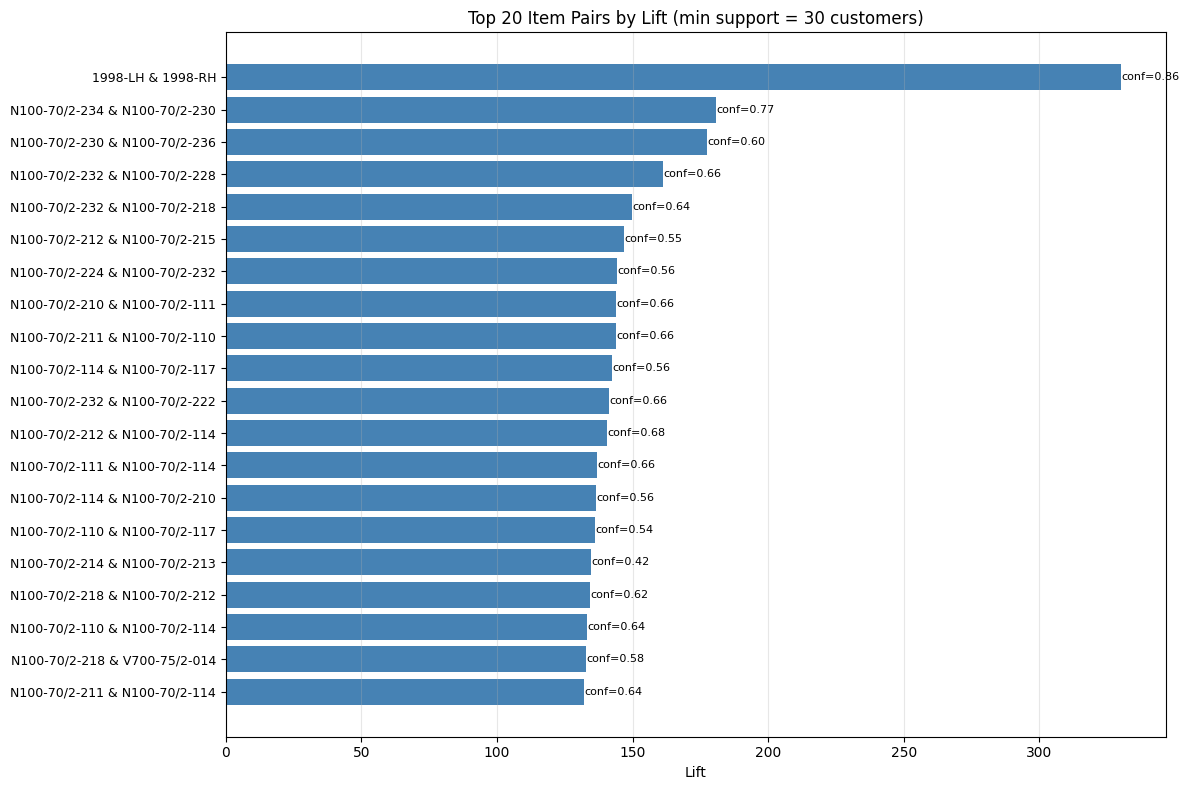


Total unique item pairs with lift > 1: 304


In [21]:
import matplotlib.pyplot as plt

# Deduplicate: keep one row per unordered pair (highest lift)
rules_dedup = rules_sorted.copy()
rules_dedup['pair'] = rules_dedup.apply(
    lambda r: tuple(sorted([r['antecedent'], r['consequent']])), axis=1
)
rules_dedup = rules_dedup.drop_duplicates(subset='pair', keep='first')

# Plot top 20 pairs by lift
top = rules_dedup.head(20)
labels = [f"{a} & {b}" for a, b in zip(top['antecedent'], top['consequent'])]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(labels)), top['lift'].values, color='steelblue')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Lift')
ax.set_title(f'Top 20 Item Pairs by Lift (min support = {min_support_count} customers)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add confidence annotations
for i, (lift_val, conf_val) in enumerate(zip(top['lift'].values, top['confidence'].values)):
    ax.text(lift_val + 0.1, i, f'conf={conf_val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTotal unique item pairs with lift > 1: {len(rules_dedup)}")

I sada 2 plota ispod pokazuju individualne frekfencije/vjerojatnosti da proizvod bude kupljen kao i postotak koliko je proizvoda kupio neki kupac. I sve skupa mi izgleda dosta zadravo kako nema neki kupac koji horda sve i nema neki proizvod koji je kupljen od strane sviju.


TOP 30 PRODUCTS BY HIGHEST PROBABILITY OF BEING BOUGHT

           item  support  customer_count
TRANSPORTKOSTEN 0.087195            1065
        *200001 0.039872             487
         OTESC1 0.030211             369
        FREIGHT 0.023416             286
          SANDH 0.019650             240
          46000 0.018340             224
          602   0.016457             201
          AUSFA 0.014983             183
         DESIGN 0.012199             149
          42000 0.011872             145
           /LTI 0.011790             144
          47000 0.010644             130
             /C 0.010316             126
        *300001 0.010234             125
          NEUBS 0.010152             124
    SAMPLE-MPCS 0.009415             115
        *200007 0.008924             109
        *200005 0.008679             106
       PROGRAMM 0.008515             104
          45000 0.007123              87
    SAMPLE-EACH 0.007041              86
         414435 0.006632              81


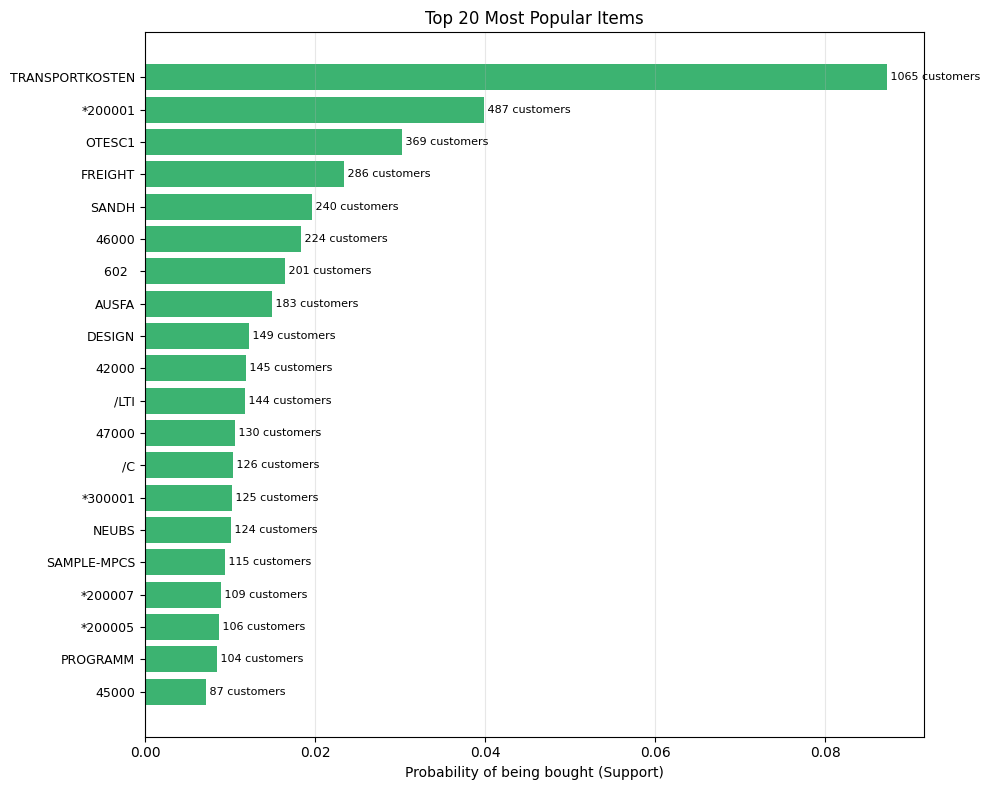

In [25]:
# Filter to only individual items (itemsets of size 1)
single_items = frequent_itemsets[frequent_itemsets['itemsets'].apply(len) == 1].copy()

# Extract the item name from the frozenset
single_items['item'] = single_items['itemsets'].apply(lambda x: list(x)[0])

# Add a column for the raw absolute customer count
single_items['customer_count'] = (single_items['support'] * len(transactions)).round().astype(int)

# Sort by highest support (probability of being bought)
top_single_items = single_items.sort_values('support', ascending=False)

print("\n" + "="*80)
print("TOP 30 PRODUCTS BY HIGHEST PROBABILITY OF BEING BOUGHT")
print("="*80 + "\n")

display_cols_single = ['item', 'support', 'customer_count']
print(top_single_items[display_cols_single].head(30).to_string(index=False))

# Plot top 20 most popular items
plt.figure(figsize=(10, 8))
top_20_single = top_single_items.head(20)
bars = plt.barh(range(len(top_20_single)), top_20_single['support'].values, color='mediumseagreen')
plt.yticks(range(len(top_20_single)), top_20_single['item'], fontsize=9)
plt.xlabel('Probability of being bought (Support)')
plt.title('Top 20 Most Popular Items')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add count annotations
for i, (supp, count) in enumerate(zip(top_20_single['support'], top_20_single['customer_count'])):
    plt.text(supp, i, f' {count} customers', va='center', fontsize=8)

plt.tight_layout()
plt.show()


TOP 30 CUSTOMERS BY NUMBER OF UNIQUE PRODUCTS BOUGHT (Total Catalog: 63019 items)

 CustomerID  Unique_Items_Count Percent_of_Catalog_Str
      19244                4134                  6.56%
     224597                1670                  2.65%
      24586                1177                  1.87%
      24254                 989                  1.57%
      24600                 967                  1.53%
      23981                 897                  1.42%
      23599                 890                  1.41%
      24085                 864                  1.37%
      24717                 835                  1.32%
     224305                 806                  1.28%
     235861                 741                  1.18%
      24041                 715                  1.13%
      24395                 648                  1.03%
      20624                 601                  0.95%
      24399                 601                  0.95%
     294128                 589     

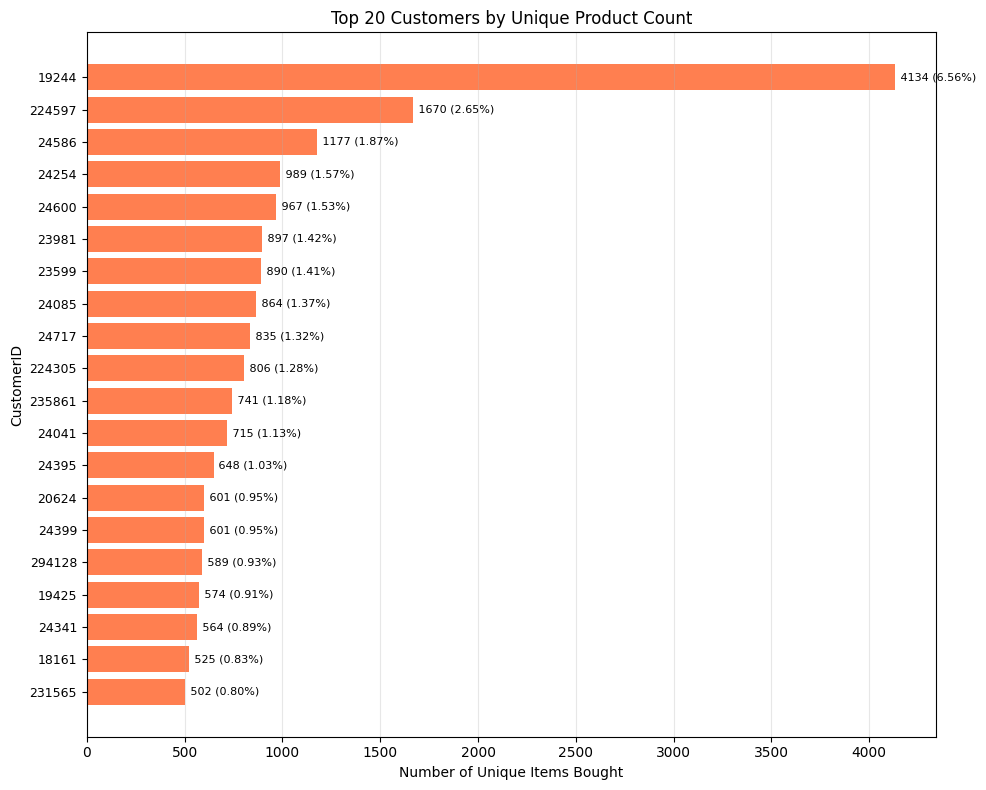

In [26]:
# Calculate the number of unique items bought by each customer (basket size)
customer_basket_sizes = {cid: len(items) for cid, items in customer_items.items()}

# Convert to a DataFrame for easy sorting and plotting
customer_baskets_df = pd.DataFrame(
    list(customer_basket_sizes.items()), 
    columns=['CustomerID', 'Unique_Items_Count']
)

# Calculate total number of unique items available in the dataset
total_unique_items = df['Item Code'].nunique()

# Add a percentage column representing the portion of the entire catalog they bought
customer_baskets_df['Percent_of_Catalog'] = (customer_baskets_df['Unique_Items_Count'] / total_unique_items) * 100

# Sort by the highest number of unique items
top_customers = customer_baskets_df.sort_values('Unique_Items_Count', ascending=False)

# Format the percentage for display
top_customers['Percent_of_Catalog_Str'] = top_customers['Percent_of_Catalog'].apply(lambda x: f"{x:.2f}%")

print("\n" + "="*80)
print(f"TOP 30 CUSTOMERS BY NUMBER OF UNIQUE PRODUCTS BOUGHT (Total Catalog: {total_unique_items} items)")
print("="*80 + "\n")
print(top_customers[['CustomerID', 'Unique_Items_Count', 'Percent_of_Catalog_Str']].head(30).to_string(index=False))

# Plot top 20 customers by basket size
plt.figure(figsize=(10, 8))
top_20_customers = top_customers.head(20)

# Convert CustomerID to string for plotting on categorical axis
bars = plt.barh(
    range(len(top_20_customers)), 
    top_20_customers['Unique_Items_Count'].values, 
    color='coral'
)

plt.yticks(range(len(top_20_customers)), top_20_customers['CustomerID'].astype(str), fontsize=9)
plt.xlabel('Number of Unique Items Bought')
plt.ylabel('CustomerID')
plt.title('Top 20 Customers by Unique Product Count')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add count and percentage annotations
for i, (count, pct) in enumerate(zip(top_20_customers['Unique_Items_Count'], top_20_customers['Percent_of_Catalog_Str'])):
    plt.text(count + 10, i, f' {count} ({pct})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

I sad nekakva ideja bi bila da kada kupac doda proizvod X u košaricu onda mu izbacimo n proizvoda tako da sortiramo listu po ocekivanoj zaradi gdje je ocekivana zarada = uvjetno da se kupi Y uvjetno da je X kupljen * marža od Y.